## Peak performance comparison between Multi-core Scan and `torch.clone` copy operator

> The goal is to understand the "peak performance" of Ascend for a simple element-wise operator like `copy` (copy-in and copy-out). We can use this benchmark as the practical peak performance of Ascend.

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [10]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [32, 64, 128]

In [11]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [ ]:
PREFIX_PATH = "../../.."

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy"
add_stats_siso(df_copy, 2)


df_baseline = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_{dtype}.csv")
df_baseline["S"] = "PyTorch"
add_stats_siso(df_baseline, 4)


df_tiled = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_mcscan_{tile}_{dtype}.csv")
    df_tmp["S"] = f"s={tile}"
    df_tiled = pd.concat([df_tiled, df_tmp])

add_stats_siso(df_tiled, 4)

df = pd.concat([df_copy, df_baseline, df_tiled])

## Paper plots

/tmp/ipykernel_1283640/3252844429.py:1: UserWarning: 
The markers list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)


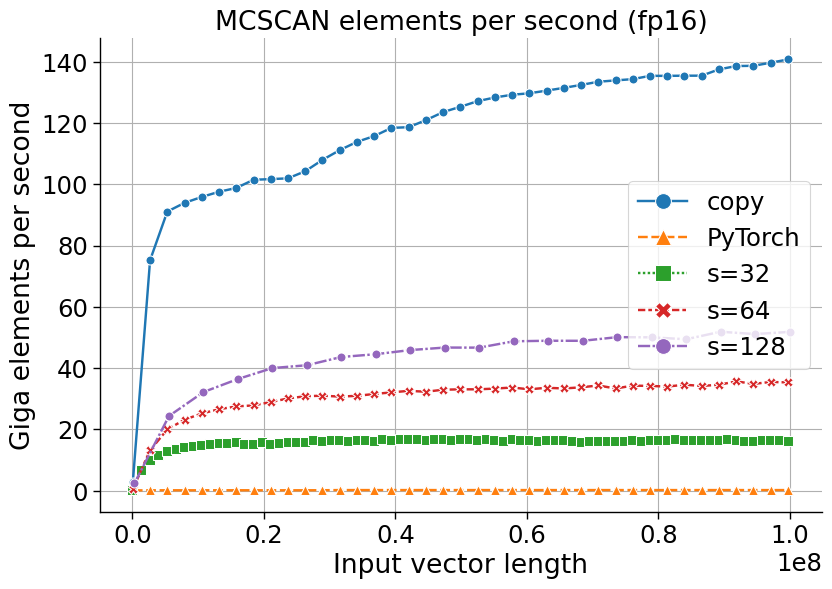

<Figure size 870x627 with 0 Axes>

In [18]:
ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN elements per second ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_gelemsps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_1283640/111434224.py:1: UserWarning: 
The markers list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)


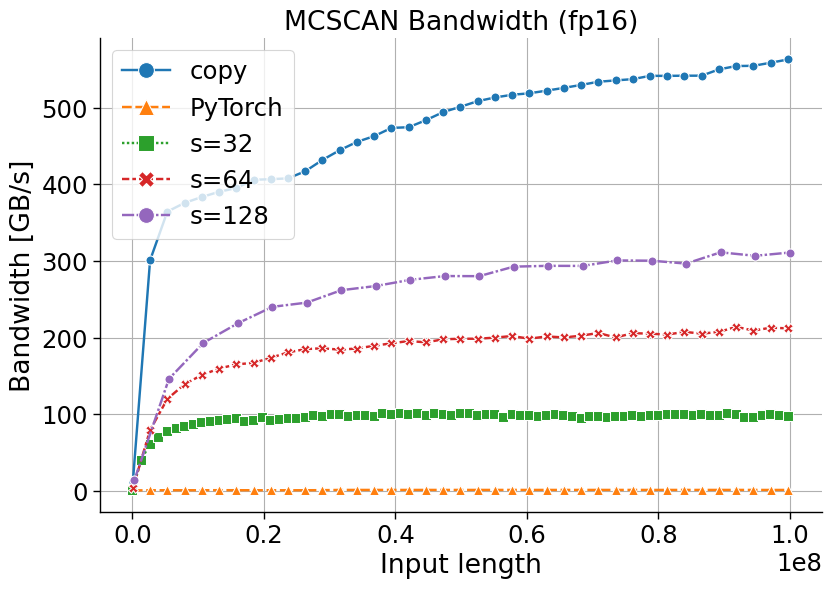

<Figure size 870x627 with 0 Axes>

In [19]:
ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_bw_{dtype}.png")
plt.show()
plt.clf()


In [15]:
df.head(100)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,copy_fp16,fp16,81920,NaN,81920,28.93,copy (fp16),2,327680,2.831663,11.326651
1,copy_fp16,fp16,2703360,NaN,2703360,35.94,copy (fp16),2,10813440,75.218698,300.874791
2,copy_fp16,fp16,5324800,NaN,5324800,58.46,copy (fp16),2,21299200,91.084502,364.338009
3,copy_fp16,fp16,7946240,NaN,7946240,84.60,copy (fp16),2,31784960,93.927187,375.708747
4,copy_fp16,fp16,10567680,NaN,10567680,110.25,copy (fp16),2,42270720,95.851973,383.407891
...,...,...,...,...,...,...,...,...,...,...,...
17,mcscan_32_fp16,fp16,22302720,NaN,22302720,1431.05,s=32,2,133816320,15.584864,93.509186
18,mcscan_32_fp16,fp16,23613440,NaN,23613440,1480.09,s=32,2,141680640,15.954057,95.724341
19,mcscan_32_fp16,fp16,24924160,NaN,24924160,1573.85,s=32,2,149544960,15.836427,95.018560
20,mcscan_32_fp16,fp16,26234880,NaN,26234880,1642.68,s=32,2,157409280,15.970779,95.824677


In [16]:
max_size = df["size"].max()
df[df["size"] >= 99 * 1e6].head(20)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
38,copy_fp16,fp16,99696640,NaN,99696640,708.58,copy (fp16),2,398786560,140.699201,562.796805
38,scan_fp16,fp16,99696640,NaN,99696640,445745.61,PyTorch,2,598179840,0.223663,1.341976
76,mcscan_32_fp16,fp16,99635200,NaN,99635200,6113.39,s=32,2,597811200,16.297864,97.787185
38,mcscan_64_fp16,fp16,99696640,NaN,99696640,2820.74,s=64,2,598179840,35.344144,212.064862
19,mcscan_128_fp16,fp16,99942400,NaN,99942400,1928.49,s=128,2,599654400,51.824173,310.945040
